1) Question 1: What is Boosting in Machine Learning? Explain how it improves weak
learners?
Boosting is an ensemble learning technique in Machine Learning that combines multiple weak learners to create a strong predictive model.

Core Idea

A weak learner (a simple model like a shallow decision tree) performs only slightly better than random guessing.
Boosting trains these models sequentially, where each new model focuses more on the mistakes made by the previous models.

How Boosting Improves Weak Learners

Sequential Learning – Models are trained one after another, not independently.

Error Focus – Misclassified samples from earlier models receive higher importance in later models.

Weighted Combination – Predictions from all models are combined (weighted voting or averaging) to produce a stronger final prediction.

Real-Time Example

In bank customer churn prediction, a single decision tree may miss complex patterns.
Boosting methods like AdaBoost or XGBoost train multiple trees sequentially, each correcting the previous one’s errors, resulting in more accurate churn prediction.

In short: Boosting converts many weak learners into a strong learner by learning from previous mistakes.

2) Difference between AdaBoost and Gradient Boosting (training approach)

AdaBoost

Models are trained sequentially, but focus is on re-weighting training samples.

Misclassified observations get higher weights, so the next model pays more attention to them.

Final prediction is a weighted vote of all models.

Gradient Boosting

Models are also trained sequentially, but each new model learns from the residual errors (difference between actual and predicted values).

Instead of changing sample weights, it optimizes a loss function using gradient descent.

Each model tries to reduce the previous model’s prediction error step by step.

Simple Example
In bank churn prediction, AdaBoost focuses more on customers wrongly predicted earlier, while Gradient Boosting builds new trees to directly correct the prediction errors (residuals) from previous models.

In short:

AdaBoost → adjusts sample weights.

Gradient Boosting → fits models on residual errors using gradient optimization.

3) Regularization in XGBoost

Regularization helps control model complexity and prevent overfitting. In XGBoost, penalties are added to the model so that trees do not become overly complex or memorize training data.

Key idea

XGBoost adds penalty terms (L1 and L2) to the loss function.

This discourages very large weights or overly deep trees, leading to better generalization.

Main types

L1 Regularization (alpha) – reduces unnecessary features by pushing some weights toward zero.

L2 Regularization (lambda) – shrinks large weights, making the model more stable.

Real-time example
In bank customer churn prediction, without regularization the model may overfit to a few customers’ unusual transaction patterns. Regularization ensures the model learns general churn behaviour, improving prediction on new customers.

In short:
Regularization in XGBoost penalizes complex models, reduces overfitting, and improves prediction reliability on unseen data.

4) CatBoost and Categorical Data

CatBoost is efficient with categorical data because it handles categories directly without heavy preprocessing.

Key points

It converts categorical variables using ordered target encoding, avoiding simple label encoding.

Reduces overfitting and data leakage while learning category relationships.

Eliminates the need for manual one-hot encoding, which saves time and memory.

Real-time example
In a bank customer churn model, variables like customer city, account type, or occupation are categorical. CatBoost automatically learns patterns from these categories and improves prediction accuracy without complex data preparation.

In short:
CatBoost efficiently processes categorical features automatically, accurately, and with less preprocessing effort.

5) Boosting vs Bagging Applications

Boosting methods such as AdaBoost, Gradient Boosting, and XGBoost are preferred when high prediction accuracy and detection of complex patterns are required.

Real-world applications

Fraud detection in banking – identifies subtle fraudulent transaction patterns.

Customer churn prediction – predicts which customers may leave a bank or telecom service.

Credit risk assessment – predicts loan default probability.

Medical diagnosis – detects diseases from patient data.

Search ranking and recommendation systems – improves relevance of results.

Example:
In banking fraud detection, boosting models sequentially correct previous mistakes and capture small abnormal patterns in transactions, leading to higher detection accuracy than bagging methods.

In [3]:
#6) # AdaBoost Classifier on Breast Cancer Dataset

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train AdaBoost model
model = AdaBoostClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9649122807017544


In [4]:
#7. Write a Python program to
#Train a Gradient Boosting Regressor on the California Housing dataset
#Evaluate performance using R-squared score
# Gradient Boosting Regressor on California Housing Dataset

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Load dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Gradient Boosting Regressor
model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate using R-squared
r2 = r2_score(y_test, y_pred)
print("R-squared Score:", r2)

R-squared Score: 0.7756446042829697


In [6]:
#8.Question 8: Write a Python program to:
# Train an XGBoost Classifier on the Breast Cancer dataset
# Tune the learning rate using GridSearchCV
#Print the best parameters and accuracy
# XGBoost Classifier with GridSearchCV (Learning Rate Tuning)

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define model
model = XGBClassifier(eval_metric='logloss', use_label_encoder=False)

# Grid search parameters (tuning learning rate)
param_grid = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2]
}

# GridSearchCV
grid = GridSearchCV(model, param_grid, cv=5)
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy)

Best Parameters: {'learning_rate': 0.2}
Accuracy: 0.956140350877193


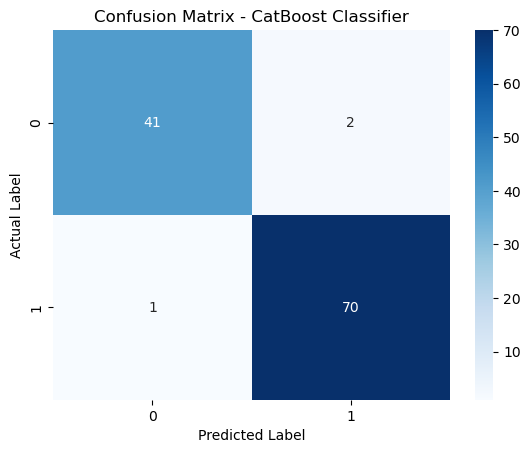

In [10]:
#9. Write a Python program to:
#Train a CatBoost Classifier
#Plot the confusion matrix using seaborn
# CatBoost Classifier with Confusion Matrix Visualization

!pip install catboost
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train CatBoost Classifier
model = CatBoostClassifier(verbose=0)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - CatBoost Classifier")
plt.show()


10) Step-by-Step Data Science Pipeline for Loan Default Prediction (Using Boosting)

1. Data Preprocessing

Handle missing values: Numerical features → median imputation; categorical features → most frequent category or “unknown”.

Encode categorical variables: If using XGBoost/AdaBoost, apply One-Hot or Label Encoding. If using CatBoost, categorical variables can be used directly.

Handle class imbalance: Apply SMOTE, class weighting, or scale_pos_weight so the model focuses on minority default cases.

Feature scaling (if needed): Mainly for AdaBoost or other models sensitive to scale.

Train–test split: Split data into training and testing sets to evaluate model generalization.

2. Choice of Boosting Algorithm

AdaBoost: Simple baseline model; works well with clean datasets but less effective with complex patterns.

XGBoost: Strong performance, handles missing values internally, supports regularization and imbalance handling.

CatBoost (preferred): Best for datasets with many categorical variables because it encodes them internally and reduces preprocessing effort.

3. Hyperparameter Tuning Strategy
Use GridSearchCV or RandomizedSearchCV with cross-validation to tune key parameters such as:

Learning rate (controls contribution of each tree)

Number of estimators (boosting rounds)

Max depth of trees

Regularization parameters (e.g., lambda, alpha in XGBoost)
This helps balance model bias and variance and avoid overfitting.

4. Evaluation Metrics
Accuracy alone is not reliable due to class imbalance, so focus on:

Precision: Avoid approving risky borrowers.

Recall: Ensure actual defaulters are detected.

F1-Score: Balance between precision and recall.

ROC-AUC: Measures overall classification performance across thresholds.

5. Business Impact

Early identification of high-risk borrowers, reducing loan default losses.

Better credit decision-making using data-driven risk scores.

Optimized loan approval strategies, improving portfolio quality.

Lower financial risk and higher profitability for the FinTech company.

In practice, this pipeline allows the company to predict defaults earlier, approve safer loans, and reduce credit risk while maintaining customer growth.